In [4]:
# Function for opening pyPhotometry data files in Python.
# Copyright (c) Thomas Akam 2018-2023.  Licenced under the GNU General Public License v3.

import os
import json
import pylab as plt
import numpy as np
from scipy.signal import butter, filtfilt, medfilt, decimate
from scipy.optimize import curve_fit
from scipy.stats import linregress, zscore
from matplotlib import pyplot as plt

# ----------------------------------------------------------------------------------
# Import ppd
# ----------------------------------------------------------------------------------


def import_ppd(file_path, low_pass=20, high_pass=0.01):
    """Function to import pyPhotometry binary data files into Python. The high_pass
    and low_pass arguments determine the frequency in Hz of highpass and lowpass
    filtering applied to the filtered analog signals. To disable highpass or lowpass
    filtering set the respective argument to None.  Returns a dictionary with the
    following items:
        'filename'      - Data filename
        'subject_ID'    - Subject ID
        'date_time'     - Recording start date and time (ISO 8601 format string)
        'end_time'      - Recording end date and time (ISO 8601 format string)
        'mode'          - Acquisition mode
        'sampling_rate' - Sampling rate (Hz)
        'LED_current'   - Current for LEDs 1 and 2 (mA)
        'version'       - Version number of pyPhotometry
        'analog_1'      - Raw analog signal 1 (volts)
        'analog_2'      - Raw analog signal 2 (volts)
        'analog_3'      - Raw analog signal 3 (if present, volts)
        'analog_1_filt' - Filtered analog signal 1 (volts)
        'analog_2_filt' - Filtered analog signal 2 (volts)
        'analog_3_filt' - Filtered analog signal 2 (if present, volts)
        'digital_1'     - Digital signal 1
        'digital_2'     - Digital signal 2 (if present)
        'pulse_inds_1'  - Locations of rising edges on digital input 1 (samples).
        'pulse_inds_2'  - Locations of rising edges on digital input 2 (samples).
        'pulse_times_1' - Times of rising edges on digital input 1 (ms).
        'pulse_times_2' - Times of rising edges on digital input 2 (ms).
        'time'          - Time of each sample relative to start of recording (ms)
    """
    with open(file_path, "rb") as f:
        header_size = int.from_bytes(f.read(2), "little")
        data_header = f.read(header_size)
        data = np.frombuffer(f.read(), dtype=np.dtype("<u2"))
    # Extract header information
    header_dict = json.loads(data_header)
    volts_per_division = header_dict["volts_per_division"]
    sampling_rate = header_dict["sampling_rate"]
    # Extract signals.
    analog = data >> 1  # Analog signal is most significant 15 bits.
    digital = ((data & 1) == 1).astype(int)  # Digital signal is least significant bit.
    # Alternating samples are different signals.
    if "n_analog_signals" in header_dict.keys():
        n_analog_signals = header_dict["n_analog_signals"]
        n_digital_signals = header_dict["n_digital_signals"]
    else:  # Pre version 1.0 data file.
        n_analog_signals = 2
        n_digital_signals = 2
    analog_1 = analog[::n_analog_signals] * volts_per_division[0]
    analog_2 = analog[1::n_analog_signals] * volts_per_division[1]
    analog_3 = analog[2::n_analog_signals] * volts_per_division[0] if n_analog_signals == 3 else None
    digital_1 = digital[::n_analog_signals]
    digital_2 = digital[1::n_analog_signals] if n_digital_signals == 2 else None
    time = np.arange(analog_1.shape[0]) * 1000 / sampling_rate  # Time relative to start of recording (ms).
    # Filter signals with specified high and low pass frequencies (Hz).
    if low_pass and high_pass:
        b, a = butter(2, np.array([high_pass, low_pass]) / (0.5 * sampling_rate), "bandpass")
    elif low_pass:
        b, a = butter(2, low_pass / (0.5 * sampling_rate), "low")
    elif high_pass:
        b, a = butter(2, high_pass / (0.5 * sampling_rate), "high")
    if low_pass or high_pass:
        analog_1_filt = filtfilt(b, a, analog_1)
        analog_2_filt = filtfilt(b, a, analog_2)
        analog_3_filt = filtfilt(b, a, analog_3) if n_analog_signals == 3 else None
    else:
        analog_1_filt = analog_2_filt = analog_3_filt = None
    # Extract rising edges for digital inputs.
    pulse_inds_1 = 1 + np.where(np.diff(digital_1) == 1)[0]
    pulse_inds_2 = 1 + np.where(np.diff(digital_2) == 1)[0] if n_digital_signals == 2 else None
    pulse_times_1 = pulse_inds_1 * 1000 / sampling_rate
    pulse_times_2 = pulse_inds_2 * 1000 / sampling_rate if n_digital_signals == 2 else None
    # Return signals + header information as a dictionary.
    data_dict = {
        "filename": os.path.basename(file_path),
        "analog_1": analog_1,
        "analog_2": analog_2,
        "analog_1_filt": analog_1_filt,
        "analog_2_filt": analog_2_filt,
        "digital_1": digital_1,
        "digital_2": digital_2,
        "pulse_inds_1": pulse_inds_1,
        "pulse_inds_2": pulse_inds_2,
        "pulse_times_1": pulse_times_1,
        "pulse_times_2": pulse_times_2,
        "time": time,
    }
    if n_analog_signals == 3:
        data_dict.update(
            {
                "analog_3": analog_3,
                "analog_3_filt": analog_3_filt,
            }
        )
    data_dict.update(header_dict)
    return data_dict


# ----------------------------------------------------------------------------------
# preprocess data
# ----------------------------------------------------------------------------------


def preprocess_data(
    data_dict=None,
    signal="analog_1",
    control="analog_2",
    sampling_rate=None,
    median_filter=False,
    low_pass=10,
    normalisation="dF/F",
    plot=False,
    fig_path=None,
):
    """Preprocess photometry data by applyling the following steps in order:

        1. Optional median filtering to remove noise spikes.
        2. Low pass filtering to reduce noise.
        3. Correction for photobleaching by subtracting a double exponential fit.
        4. Motion correction by subtracting linear fit of control channel from signal channel.
           Steps 1-3 are applied to signal and control channels prior to motion correction.
        5. Optional normalisation by computing  dF/F or z-score.

    Adapted from https://github.com/ThomasAkam/photometry_preprocessing

    Parameters:
        data_dict : data dictionary generated by import_ppd function (optional).
        signal : String correponding to the key data_dict to use as the signal channel, or
                 a numpy array containg the signal channel data.
        control : String correponding to the key data_dict to use as the control channel, or
                 a numpy array containg the control channel data.
        sampling_rate : Sampling rate in Hz, only used if data_dict is not provided.
        median_filter : Width of median filter window in samples, set False to disable median filtering.
        lowpass : Frequency of low pass filtering in Hz.
        normalisation : Type of normalisation to apply; 'dF/F', 'z-score' or None.
        plot : Set True to plot raw and processed signals.
        fig_path : Specify a file path (including file extension) to save the plotted figure.
    Returns:
        signal_norm : Numpy array containing the signal after preprocessing and normalisation.
    """
    assert normalisation in ("dF/F", "z-score", None), "normalisation must be 'dF/F', 'z-score' or None"
    if data_dict:  # Extract variables from data dict.
        signal = data_dict[signal]
        control = data_dict[control]
        sampling_rate = data_dict["sampling_rate"]
    # Filtering to remove noise.
    b, a = butter(2, low_pass, btype="low", fs=sampling_rate)
    if median_filter:  # Median filter + lowpass filter.
        signal_filt = filtfilt(b, a, medfilt(signal, median_filter))
        control_filt = filtfilt(b, a, medfilt(control, median_filter))
    else:  # Lowpass filter.
        signal_filt = filtfilt(b, a, signal)
        control_filt = filtfilt(b, a, control)
    # Photobleaching correction by subtracting double exponential fit.
    t = np.arange(len(signal)) / sampling_rate
    signal_expfit = _fit_exponential(signal_filt, t, sampling_rate)
    control_expfit = _fit_exponential(control_filt, t, sampling_rate)
    signal_bc = signal_filt - signal_expfit
    control_bc = control_filt - control_expfit
    # Motion correction.
    slope, intercept, r_value, p_value, std_err = linregress(x=control_bc, y=signal_bc)
    est_motion = intercept + slope * control_bc
    signal_mc = signal_bc - est_motion
    # Normalisation.
    if normalisation == "dF/F":
        signal_norm = 100 * signal_mc / signal_expfit
    elif normalisation == "z-score":
        signal_norm = zscore(signal_mc)
    else:
        signal_norm = signal_mc
    # Plotting
    if plot or fig_path:
        # Plot raw signals.
        fig = plt.figure(1, clear=True, figsize=[12, 8])
        ax1 = plt.subplot(2, 3, (1, 2))
        plt.plot(t, signal, label="Signal")
        plt.plot(t, signal_expfit, "k")
        plt.plot(t, control, label="Control")
        plt.plot(t, control_expfit, "k")
        plt.legend(loc="upper right")
        plt.ylabel("Raw signal (Volts)")
        plt.xlim(0, t[-1])
        ax1.text(x=0, y=1.02, s=data_dict["filename"][:-4] if data_dict else "", transform=ax1.transAxes)
        # # Plot processed signal.
        plt.subplot(2, 3, (4, 5), sharex=ax1)
        plt.plot(t, signal_norm)
        plt.xlabel("Time (seconds)")
        plt.ylabel(f"Processed signal {normalisation}")
        plt.xlim(0, t[-1])
        ax2 = plt.subplot(2, 3, 3)
        control_bc_dec = control_bc[::10]
        signal_bc_dec = signal_bc[::10]
        plt.scatter(control_bc_dec, signal_bc_dec, alpha=0.1, marker=".")
        plt.xlim(1.5 * np.percentile(control_bc_dec, [1, 99]))
        plt.ylim(2 * np.percentile(signal_bc_dec, [1, 99]))
        x = np.array(plt.xlim())
        plt.plot(x, intercept + slope * x)
        plt.xlabel("Control (post bleaching correction)")
        plt.ylabel("Signal (post bleaching correction)")
        ax2.text(x=0.05, y=0.95, s=f"slope: {slope :.2f}", transform=ax2.transAxes)
        plt.subplot(2, 3, 6)
        plt.plot(t, signal_norm)
        plt.xlim(0, 10)
        plt.xlabel("Time (seconds)")
        plt.ylabel(f"Processed signal {normalisation}")
        plt.tight_layout()
        if fig_path:
            fig.savefig(fig_path)
    return signal_norm


def _fit_exponential(signal, t, sampling_rate):
    """Fit a double exponential to the signal after downsampling to 1Hz.
    Parameters:
        signal: signal to be fitted
        t     : time vector in seconds.
    Returns:
        Fitted curve.
    """
    max_sig = np.max(signal)
    signal_ds = decimate(signal, int(sampling_rate))
    t_ds = decimate(t, sampling_rate)
    init_params = [max_sig / 2, max_sig / 4, max_sig / 4, 300, 3000]
    bounds = ([0, 0, 0, 60, 600], [max_sig, max_sig, max_sig, 600, 36000])
    params, parm_cov = curve_fit(_double_exponential, t_ds, signal_ds, p0=init_params, bounds=bounds, maxfev=1000)
    return _double_exponential(t, *params)


def _double_exponential(t, const, amp_fast, amp_slow, tau_fast, tau_slow):
    """Compute a double exponential function with constant offset.
    Parameters:
        t       : Time vector in seconds.
        const   : Amplitude of the constant offset.
        amp_fast: Amplitude of the fast component.
        amp_slow: Amplitude of the slow component.
        tau_fast: Time constant of fast component in seconds.
        tau_slow: Time constant of slow component in seconds.
    """
    return const + amp_slow * np.exp(-t / tau_slow) + amp_fast * np.exp(-t / tau_fast)

In [5]:
data = import_ppd(file_path=r"C:\data\raw\M089\M089_2025_11_05_15_00\M089_2025_11_05_15_00-2025-11-05-145302.ppd")

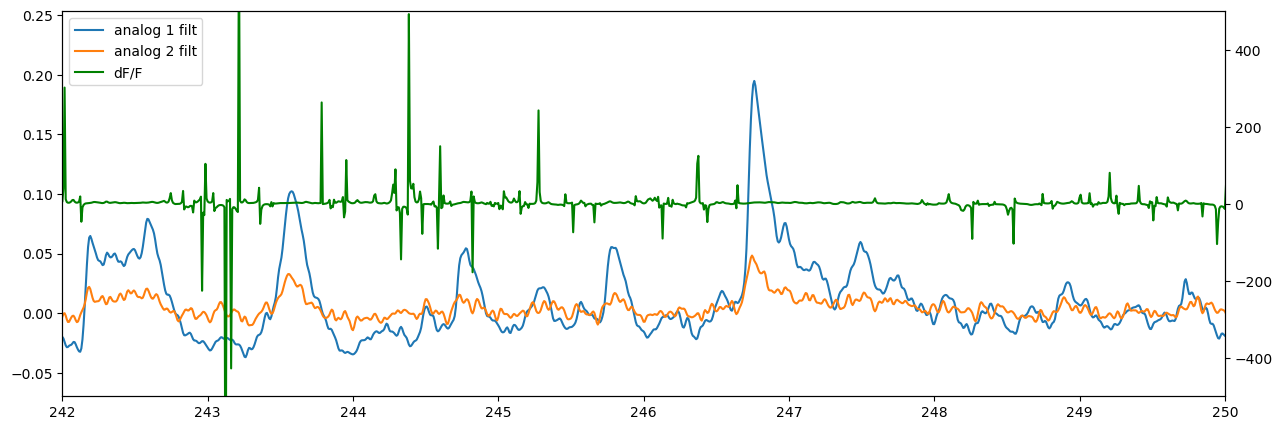

In [59]:
plt.close('all')
fig, ax1 = plt.subplots(figsize=[15, 5])
ax2 = ax1.twinx()

ax1.plot(data['time']/1000,data['analog_1_filt'], label='analog 1 filt')
ax1.plot(data['time']/1000,data['analog_2_filt'], label='analog 2 filt')
ax2.plot(data['time']/1000,
    (data['analog_1_filt']- data['analog_2_filt']) / data['analog_2_filt'],
    label='dF/F',
    color='green'
    )

# plt.plot(data['time']/1000,data['digital_1'], label='analog 2 filt')

ax1.set_xlim(242,250)
ax2.set_xlim(*ax1.get_xlim())
ax2.set_ylim(-500,500)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
plt.show()

In [61]:
data['analog_2_filt']

array([-0.00608828, -0.01026842, -0.01149723, ...,  0.02158327,
        0.01771522,  0.00967282], shape=(43508,))